In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import rainbow
import OPS

# For Labeling Metrics

## o-value of f1

In [2]:
# for example, the positive class ratio is 0.1, the f1_score is 0.6
pi=0.1
f1=0.6
# then, the o-value is
OPS.O_f1(f1, pi)

0.9576719576719577

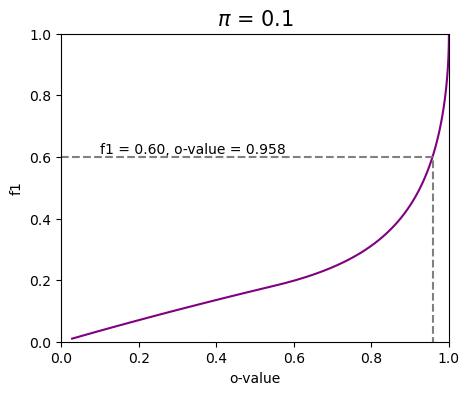

In [3]:
# we can plot the o-value of f1_score for all possible values in [0,1]

fig = plt.figure(figsize=(5,4))

f1_list = (np.arange(100)+1)/100
f1_list = f1_list.tolist()
OPS_f = []

for value in f1_list:
    OPS_f.append(OPS.O_f1(value, pi))
    
plt.plot(OPS_f, f1_list, color='purple')
plt.plot([0,OPS.O_f1(f1, pi),OPS.O_f1(f1, pi)], [f1,f1,0], linestyle='--', color='gray')
plt.annotate('f1 = %0.2f' % f1 + ', o-value = %0.3f' % OPS.O_f1(f1, pi), xy=(0.1, f1+0.01))

plt.title(r'$\pi$ = %0.1f' % pi, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('f1')
plt.xlim([0.0, 1.0])        
plt.ylim([0.0, 1.0])
plt.show()

## o-value of MCC

In [4]:
# for example, the positive class ratio pi is 0.1, the MCC is 0.4
pi=0.1
mcc=0.4
# then, the o-value is
OPS.O_MCC(mcc, pi)

0.8949958133257554

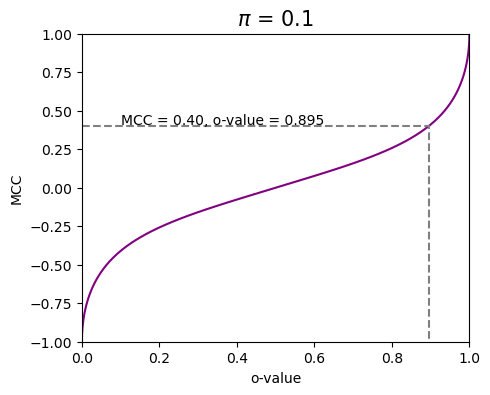

In [5]:
# we can plot the o-value of MCC for all possible values in [-1,1]

fig = plt.figure(figsize=(5,4))

mcc_list = (np.arange(100)+1)/50 - 1
mcc_list = mcc_list.tolist()
OPS_mcc = []

for value in mcc_list:
    OPS_mcc.append(OPS.O_MCC(value, pi))
    
plt.plot(OPS_mcc, mcc_list, color='purple')
plt.plot([0,OPS.O_MCC(mcc, pi),OPS.O_MCC(mcc, pi)], [mcc,mcc,-1], linestyle='--', color='gray')
plt.annotate('MCC = %0.2f' % mcc + ', o-value = %0.3f' % OPS.O_MCC(mcc, pi), xy=(0.1, mcc+0.01))
plt.title(r'$\pi$ = %0.1f' % pi, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('MCC')
plt.xlim([0.0, 1.0])        
plt.ylim([-1.0, 1.0])
plt.show()

# For Scoring Metrics

## 1. PRC 

In [6]:
# for example, the positive class ratio is 0.1
pi = 0.1
OPS_prc = OPS.ScoringM(pi, curve='prc')  # define a o-value estimator for PRC given pi=0.1

### OPS_AUC(PRC)

In [7]:
# AUC(PRC): the area under the PRC
# if the AUC(PRC) is 0.6, then its o-value is
auc = 0.6
OPS_prc.O_AUC(auc)

0.962125

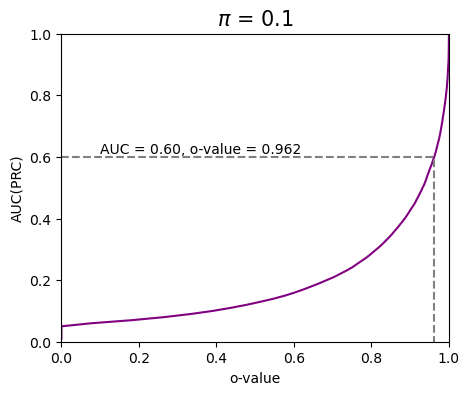

In [8]:
# we can plot the o-value of AUC(PRC) for all possible values in [0,1]

fig = plt.figure(figsize=(5,4))

auc_list = (np.arange(100)+1)/100
auc_list = auc_list.tolist()
OPS_auc = []

for value in auc_list:
    OPS_auc.append(OPS_prc.O_AUC(value))
    
plt.plot(OPS_auc, auc_list, color='purple')
plt.plot([0,OPS_prc.O_AUC(auc),OPS_prc.O_AUC(auc)], [auc,auc,0], linestyle='--', color='gray')
plt.annotate('AUC = %0.2f' % auc + ', o-value = %0.3f' % OPS_prc.O_AUC(auc), xy=(0.1, auc+0.01))
plt.title(r'$\pi$ = %0.1f' % pi, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('AUC(PRC)')
plt.xlim([0.0, 1.0])        
plt.ylim([0.0, 1.0])
plt.show()

### OPS_Precision|Recall 

In [9]:
# In event detection tasks, we usually want to evaluate how good the precision is given a specific recall
# for example, recall is 0.9, precision is 0.4
recall = 0.9
precision = 0.4

# then, the o-value is
OPS_prc.SimulateY(X=recall)
OPS_prc.O_Y(precision)

0.973175

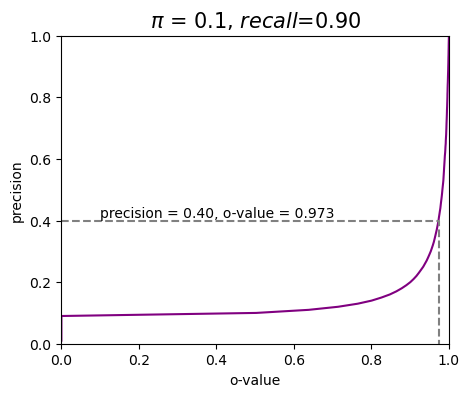

In [10]:
# we can plot the o-value of precision for all possible values in [0,1] given recall=0.9

fig = plt.figure(figsize=(5,4))

pre_list = (np.arange(100)+1)/100
pre_list = pre_list.tolist()
OPS_pre = []

for value in pre_list:
    OPS_pre.append(OPS_prc.O_Y(value))
    
plt.plot(OPS_pre, pre_list, color='purple')
plt.plot([0,OPS_prc.O_Y(precision),OPS_prc.O_Y(precision)], [precision,precision,0], linestyle='--', color='gray')
plt.annotate('precision = %0.2f' % precision + ', o-value = %0.3f' % OPS_prc.O_Y(precision), xy=(0.1, precision+0.01))
plt.title(r'$\pi$ = %0.1f, ' % pi + r'$recall$=%0.2f' % recall, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('precision')
plt.xlim([0.0, 1.0])        
plt.ylim([0.0, 1.0])
plt.show()

## 1. Lift Curve

In [11]:
# for example, the positive class ratio is 0.1
pi = 0.1
OPS_lift = OPS.ScoringM(pi, curve='lift')  # define a o-value estimator for lift curve given pi=0.1

### o-value of AUC(Lift)

In [12]:
# the idea or maximum AUC(Lift) is
idea_lift_auc = 1 - np.log(pi)
print(idea_lift_auc)

3.3025850929940455


In [13]:
# if the AUC(Lift) is 2.5, then its o-value is
auc = 2.5
OPS_lift.O_AUC(auc)

0.9555

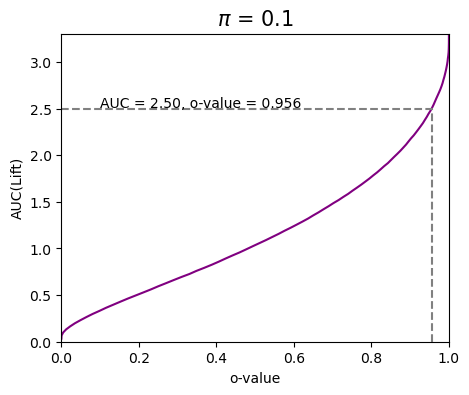

In [14]:
# we can plot the o-value of AUC(Lift) for all possible values in [0,idea_lift_auc]

fig = plt.figure(figsize=(5,4))

auc_list = idea_lift_auc*(np.arange(100)+1)/100
auc_list = auc_list.tolist()
OPS_auc = []

for value in auc_list:
    OPS_auc.append(OPS_lift.O_AUC(value))
    
plt.plot(OPS_auc, auc_list, color='purple')
plt.plot([0,OPS_lift.O_AUC(auc),OPS_lift.O_AUC(auc)], [auc,auc,0], linestyle='--', color='gray')
plt.annotate('AUC = %0.2f' % auc + ', o-value = %0.3f' % OPS_lift.O_AUC(auc), xy=(0.1, auc+0.01))
plt.title(r'$\pi$ = %0.1f' % pi, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('AUC(Lift)')
plt.xlim([0.0, 1.0])        
plt.ylim([0.0, idea_lift_auc])
plt.show()

### o-value of Lift@Percentage 

In [15]:
# For Recommandation models, we usually want to evaluate how good the lift is by recommanding a given percentage of samples 
# for example, lift is 4, percentage is 20%
lift = 4
percentage = 0.2

# then, the o-value is
OPS_lift.SimulateY(X=percentage)
OPS_lift.O_Y(lift)

0.94815

In [16]:
# the idea or maximum lift for a given percentage is 
idea_lift = min(1/pi, 1/percentage)
print(idea_lift)

5.0


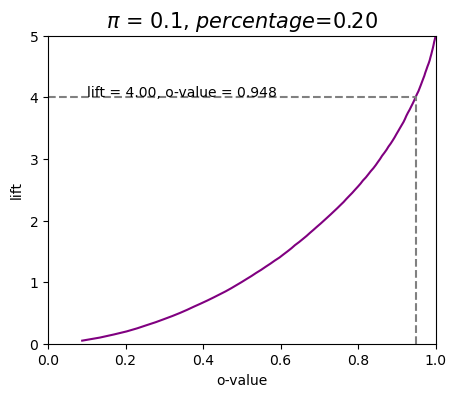

In [17]:
# we can plot the o-value of lift for all possible values in [0,idea_lift] given percentage=0.2

fig = plt.figure(figsize=(5,4))

lift_list = idea_lift*(np.arange(100)+1)/100
lift_list = lift_list.tolist()
OPS_lift_list = []

for value in lift_list:
    OPS_lift_list.append(OPS_lift.O_Y(value))
    
plt.plot(OPS_lift_list, lift_list, color='purple')
plt.plot([0,OPS_lift.O_Y(lift),OPS_lift.O_Y(lift)], [lift,lift,0], linestyle='--', color='gray')
plt.annotate('lift = %0.2f' % lift + ', o-value = %0.3f' % OPS_lift.O_Y(lift), xy=(0.1, lift+0.01))
plt.title(r'$\pi$ = %0.1f, ' % pi + r'$percentage$=%0.2f' % percentage, fontsize=15)
plt.xlabel('o-value')
plt.ylabel('lift')
plt.xlim([0.0, 1.0])        
plt.ylim([0.0, idea_lift])
plt.show()